In [1]:
# ==============================
#  DERMATOLOGY AI PROJECT SETUP
# ==============================

import os
import zipfile
import numpy as np
import tensorflow as tf
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define project path
PROJECT_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"
DATASET_PATH = f"{PROJECT_PATH}/datasets"

# ZIP file paths
ISIC_ZIP = f"{DATASET_PATH}/ISIC2018_segmentation.zip"
HAM_ZIP = f"{DATASET_PATH}/HAM10000.zip"

print("Project Path:", PROJECT_PATH)
print("Dataset Path:", DATASET_PATH)

# Move to project directory
os.chdir(PROJECT_PATH)
print("Current Working Directory:", os.getcwd())

Mounting Google Drive...
Mounted at /content/drive
Project Path: /content/drive/MyDrive/Dermatology_AI_Project
Dataset Path: /content/drive/MyDrive/Dermatology_AI_Project/datasets
Current Working Directory: /content/drive/MyDrive/Dermatology_AI_Project


In [2]:
!pip install scikit-image

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import measure
from skimage.color import rgb2gray

In [8]:
BASE_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"

TEST_IMAGE_PATH = BASE_PATH + "/test_images"
MODEL_PATH = BASE_PATH + "/models"
RESULT_PATH = BASE_PATH + "/results/severity_analysis"

os.makedirs(RESULT_PATH, exist_ok=True)

In [77]:
MASK_SAVE_PATH = RESULT_PATH + "/segmentation_masks"
os.makedirs(MASK_SAVE_PATH, exist_ok=True)

REPORT_PATH = RESULT_PATH + "/severity_reports"
os.makedirs(REPORT_PATH, exist_ok=True)

In [12]:
from tensorflow.keras.models import load_model

segmentation_model_path = MODEL_PATH + "/unet_segmentation_best.h5"

unet_model = load_model(segmentation_model_path, compile=False)

print("U-Net model loaded successfully")

U-Net model loaded successfully


In [13]:
print(type(unet_model))

<class 'keras.src.models.functional.Functional'>


(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

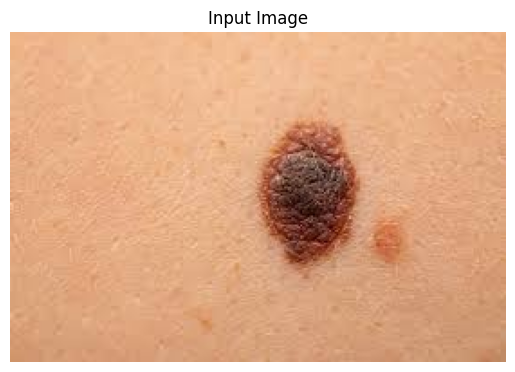

In [15]:
image_list = os.listdir(TEST_IMAGE_PATH)

sample_image = image_list[0]

image_path = os.path.join(TEST_IMAGE_PATH, sample_image)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

In [19]:
img_resized = cv2.resize(image, (128,128))

img_norm = img_resized / 255.0

input_img = np.expand_dims(img_norm, axis=0)

In [20]:
pred_mask = unet_model.predict(input_img)[0]

pred_mask = (pred_mask > 0.5).astype(np.uint8)

pred_mask = pred_mask[:,:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


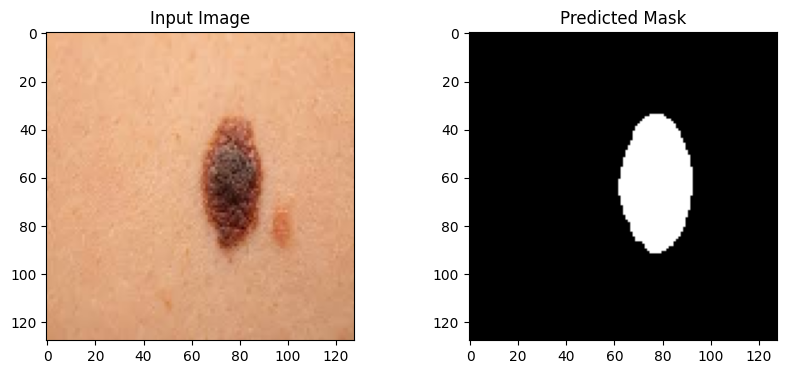

In [21]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")

plt.show()

In [22]:
lesion_area = np.sum(pred_mask)

print("Lesion Area:", lesion_area)

Lesion Area: 1338


In [23]:
contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

perimeter = cv2.arcLength(contours[0], True)

print("Perimeter:", perimeter)

Perimeter: 147.63960909843445


In [24]:
x,y,w,h = cv2.boundingRect(contours[0])

diameter = max(w,h)

print("Diameter:", diameter)

Diameter: 58


In [25]:
import math

irregularity = (perimeter**2) / (4 * math.pi * lesion_area)

print("Border Irregularity:", irregularity)

Border Irregularity: 1.296402308941968


In [26]:
masked_pixels = img_resized[pred_mask > 0]

color_variance = np.var(masked_pixels)

print("Color Variance:", color_variance)

Color Variance: 2980.634637513099


In [27]:
mask_flip = np.fliplr(pred_mask)

overlap = np.logical_and(pred_mask, mask_flip)

asymmetry_score = 1 - (np.sum(overlap) / np.sum(pred_mask))

print("Asymmetry Score:", asymmetry_score)

Asymmetry Score: 0.9656203288490284


In [28]:
area_score = min(lesion_area / 5000, 1)

border_score = min(irregularity / 3, 1)

color_score = min(color_variance / 1000, 1)

diameter_score = min(diameter / 128, 1)

In [29]:
severity_score = (
    0.25 * asymmetry_score +
    0.25 * border_score +
    0.25 * color_score +
    0.25 * diameter_score
)

print("Severity Score:", severity_score)

Severity Score: 0.7127198579574211


In [30]:
if severity_score < 0.4:
    risk_level = "LOW"

elif severity_score < 0.7:
    risk_level = "MODERATE"

else:
    risk_level = "HIGH"

print("Risk Level:", risk_level)

Risk Level: HIGH


In [31]:
if risk_level == "LOW":
    recommendation = "Monitor lesion periodically"

elif risk_level == "MODERATE":
    recommendation = "Dermatology check recommended"

else:
    recommendation = "Urgent dermatologist consultation"

print("Recommendation:", recommendation)

Recommendation: Urgent dermatologist consultation


In [32]:
print("\n===== AI Dermatology Severity Report =====")

print(f"Lesion Area: {lesion_area}")
print(f"Border Irregularity: {irregularity:.2f}")
print(f"Asymmetry Score: {asymmetry_score:.2f}")
print(f"Color Variance: {color_variance:.2f}")
print(f"Diameter: {diameter}")

print("\nSeverity Score:", round(severity_score,2))
print("Risk Level:", risk_level)
print("Clinical Recommendation:", recommendation)

print("=========================================")


===== AI Dermatology Severity Report =====
Lesion Area: 1338
Border Irregularity: 1.30
Asymmetry Score: 0.97
Color Variance: 2980.63
Diameter: 58

Severity Score: 0.71
Risk Level: HIGH
Clinical Recommendation: Urgent dermatologist consultation


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


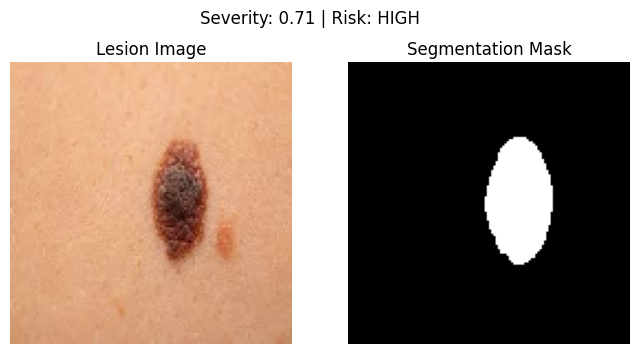

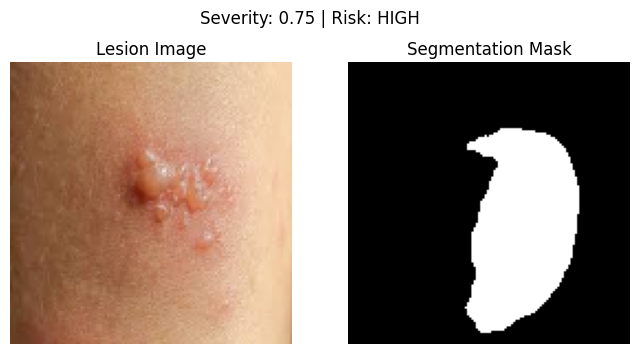

In [87]:
results = []

image_list = os.listdir(TEST_IMAGE_PATH)

for img_name in image_list:
  image_list = os.listdir(TEST_IMAGE_PATH)

for img_name in image_list:

    if not img_name.lower().endswith((".png",".jpg",".jpeg")):
        continue

    try:
        img_path = os.path.join(TEST_IMAGE_PATH, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize for U-Net
        img_resized = cv2.resize(image, (128,128))
        img_norm = img_resized / 255.0
        input_img = np.expand_dims(img_norm, axis=0)

        # Generate mask
        pred_mask = unet_model.predict(input_img)[0]
        pred_mask = (pred_mask > 0.5).astype(np.uint8)
        pred_mask = pred_mask[:,:,0]

        mask_filename = img_name.split(".")[0] + "_mask.png"

        cv2.imwrite(
        os.path.join(MASK_SAVE_PATH, mask_filename),
        pred_mask * 255
        )

        lesion_area = np.sum(pred_mask)

        contours,_ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            print("No lesion detected:", img_name)
            continue

        perimeter = cv2.arcLength(contours[0], True)

        x,y,w,h = cv2.boundingRect(contours[0])
        diameter = max(w,h)

        irregularity = (perimeter**2) / (4 * np.pi * lesion_area + 1)

        masked_pixels = img_resized[pred_mask > 0]

        if len(masked_pixels) == 0:
            continue

        color_variance = np.var(masked_pixels)

        mask_flip = np.fliplr(pred_mask)
        overlap = np.logical_and(pred_mask, mask_flip)

        asymmetry_score = 1 - (np.sum(overlap) / (np.sum(pred_mask) + 1))

        area_score = min(lesion_area / 5000, 1)
        border_score = min(irregularity / 3, 1)
        color_score = min(color_variance / 1000, 1)
        diameter_score = min(diameter / 128, 1)

        severity_score = (
            0.25 * asymmetry_score +
            0.25 * border_score +
            0.25 * color_score +
            0.25 * diameter_score
        )

        if severity_score < 0.4:
            risk_level = "LOW"
        elif severity_score < 0.7:
            risk_level = "MODERATE"
        else:
            risk_level = "HIGH"

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.imshow(img_resized)
        plt.title("Lesion Image")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Segmentation Mask")
        plt.axis("off")

        plt.suptitle(
        f"Severity: {severity_score:.2f} | Risk: {risk_level}",
        fontsize=12
        )

        # ===== Create Overlay Image =====

        overlay_img = img_resized.copy()

        # Draw lesion contour
        cv2.drawContours(overlay_img, contours, -1, (255,0,0), 2)

        # Draw bounding box (diameter visualization)
        cv2.rectangle(overlay_img, (x,y), (x+w, y+h), (0,255,0), 2)

        # Add severity text
        cv2.putText(
        overlay_img,
        f"Severity: {severity_score:.2f} | {risk_level}",
        (5,15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        (255,255,255),
        1
        )


        # ===== Generate Report Figure =====

        plt.figure(figsize=(10,4))

        plt.subplot(1,3,1)
        plt.imshow(img_resized)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Segmentation Mask")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(overlay_img)
        plt.title("AI Analysis")
        plt.axis("off")

        plt.suptitle(
        f"AI Dermatology Severity Report\nRisk Level: {risk_level}",
        fontsize=12
        )

        report_file = img_name.split(".")[0] + "_severity_report.png"

        plt.savefig(os.path.join(REPORT_PATH, report_file))
        plt.close()

        results.append({
            "image": img_name,
            "area": lesion_area,
            "diameter": diameter,
            "asymmetry": asymmetry_score,
            "severity_score": severity_score,
            "risk_level": risk_level
        })

    except Exception as e:
        print("Error processing:", img_name)
        print(e)

In [88]:
severity_df = severity_df.drop_duplicates()
severity_df = pd.DataFrame(results)
severity_df




,image,area,diameter,asymmetry,severity_score,risk_level
0,lesion.jpg,1338,58,0.965646,0.712720,HIGH
1,lesion2.jpg,3531,93,0.719706,0.748686,HIGH


In [89]:
csv_path = RESULT_PATH + "/severity_analysis_results.csv"
severity_df.to_csv(csv_path, index=False)

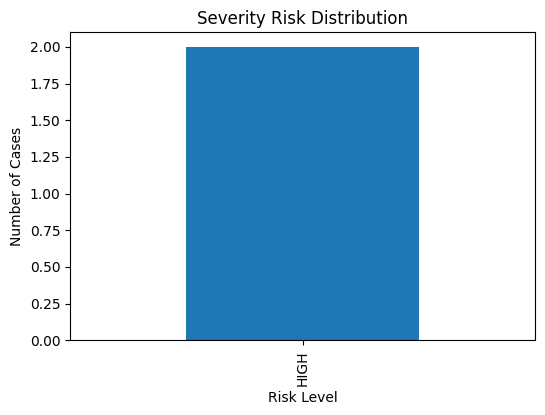

In [90]:
plt.figure(figsize=(6,4))

severity_df["risk_level"].value_counts().plot(kind="bar")

plt.title("Severity Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Cases")

plt.show()

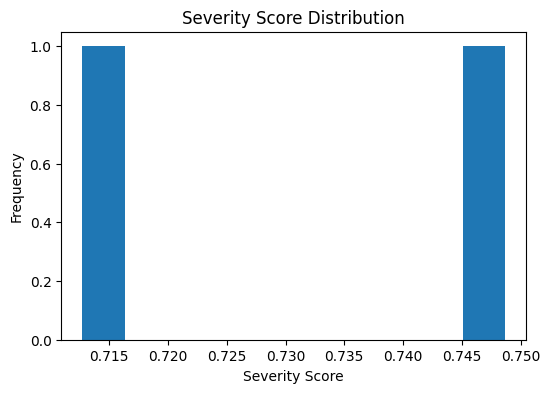

In [91]:
plt.figure(figsize=(6,4))

plt.hist(severity_df["severity_score"], bins=10)

plt.title("Severity Score Distribution")
plt.xlabel("Severity Score")
plt.ylabel("Frequency")

plt.show()

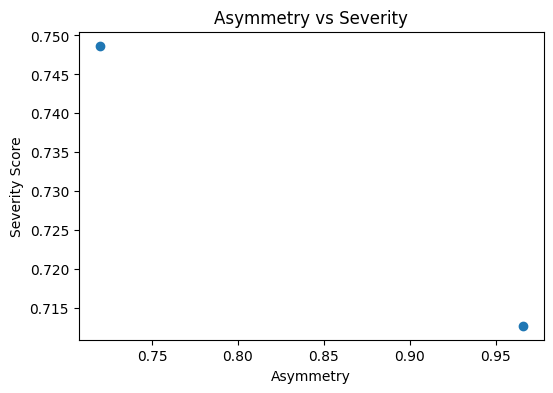

In [92]:
plt.figure(figsize=(6,4))

plt.scatter(severity_df["asymmetry"], severity_df["severity_score"])

plt.xlabel("Asymmetry")
plt.ylabel("Severity Score")

plt.title("Asymmetry vs Severity")

plt.show()